In [ ]:
#!pip install scikit-learn

In [12]:
import numpy as np
from numpy import ndarray
from torchvision import datasets
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split



plt.style.use('dark_background')



### Реализация SGD + momentum.

In [63]:
class SGD:
    """
    SGD optimizer + momentum
    """
    def __init__(self, lr: float = 1e-3, beta1: float = 0.9, weight_decay: float = 0):
        self.lr = lr
        self.beta1 = beta1
        self.weight_decay = weight_decay

        # Состояния оптимизатора.
        self.m = []

    def step(self, params: list[ndarray], grads: list[ndarray]) -> list[ndarray]:
        """
        Выполняет один шаг оптимизации.

        Args:
            params: list[ndarray] – текущие параметры модели
            grads:  list[ndarray] – градиенты для параметров
            
        Returns:
            list[np.ndarray] – обновлённые параметры
        """

        for i, (param, grad) in enumerate(zip(params, grads)):

            # Инициализация состояний при первом шаге
            if len(self.m) != len(params):
                self.m.append(np.zeros_like(param))

            m = self.m[i]

            # Обновление скользящего среднего
            m = self.beta1 * m + grad

            # SGD + momentum: шаг опритизации
            param_new = (
                param
                - self.lr * m
                - self.lr * self.weight_decay * param
            )

            # Сохраняем состояния и новые параметры
            self.m[i] = m
            params[i] = param_new

        return params
    
    

### Реализация RMSprop.

In [64]:
class RMSprop:
    """
    RMSprop optimizer.
    """
    def __init__(
            self,
            lr: float = 1e-3,
            beta2: float = 0.999,
            eps: float = 1e-8,
            weight_decay: float = 0
    ):
        self.lr = lr
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay

        # Состояния оптимизатора.
        self.v = []

    def step(self, params: list[ndarray], grads: list[ndarray]) -> list[ndarray]:
        """
        Выполняет один шаг оптимизации.
        
        Args:
            params: list[np.ndarray] – текущие параметры модели
            grads:  list[np.ndarray] – градиенты для параметров
            
        Returns:
            list[np.ndarray] – обновлённые параметры
        """

        for i, (param, grad) in enumerate(zip(params, grads)):

            # Инициализация состояний при первом шаге
            if len(self.v) != len(params):
                self.v.append(np.zeros_like(param))
            
            v = self.v[i]

            # Обновление скользящего среднего
            v = self.beta2 * v + (1 - self.beta2) * np.square(grad)

            # RMSprop: шаг опритизации
            lr_step = self.lr / (np.sqrt(v) + self.eps)
            param_new = (
                param
                - lr_step * grad
                - self.lr * self.weight_decay * param
            )

            # Сохраняем состояния и новые параметры
            self.v[i] = v
            params[i] = param_new

        return params

### Реализация AdamW.

In [4]:
class AdamW:
    """
    AdamW optimizer.
    """
    def __init__(
            self,
            lr: float = 1e-3,
            beta1: float = 0.9,
            beta2: float = 0.999,
            eps: float = 1e-8,
            weight_decay: float = 1e-2
    ):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay
        self.t = 0  # счётчик шагов

        # Состояния оптимизатора: первые и вторые моменты
        self.m = []
        self.v = []

    def step(self, params: list[ndarray], grads: list[ndarray]) -> list[ndarray]:
        """
        Выполняет один шаг оптимизации.
        
        Args:
            params: list[np.ndarray] – текущие параметры модели
            grads:  list[np.ndarray] – градиенты для параметров
            
        Returns:
            list[np.ndarray] – обновлённые параметры
        """
        self.t += 1

        for i, (param, grad) in enumerate(zip(params, grads)):

            # Инициализация состояний при первом шаге
            if len(self.v) != len(params):
                self.m.append(np.zeros_like(param))
                self.v.append(np.zeros_like(param))

            m = self.m[i]
            v = self.v[i]

            # Обновление скользящих средних
            m = self.beta1 * m + (1 - self.beta1) * grad
            v = self.beta2 * v + (1 - self.beta2) * np.square(grad)

            # Коррекция смещения
            m_hat = m / (1 - self.beta1 ** self.t)
            v_hat = v / (1 - self.beta2 ** self.t)

            # AdamW: шаг оптимизации
            adam_step = m_hat / (np.sqrt(v_hat) + self.eps)
            param_new = (
                param
                - self.lr * adam_step
                - self.lr * self.weight_decay * param
            )

            # Сохраняем состояния и новые параметры
            self.m[i] = m
            self.v[i] = v
            params[i] = param_new

        return params

### Обучение сети.

In [ ]:
class CrossEntropyLoss:
    """
    Функция потерь Cross-Entropy для задач многоклассовой классификации.
    Реализация: Softmax + Cross-Entropy Loss.
    """

    def forward(self, pred: ndarray, target: ndarray) -> float:
        """
        Прямой проход через Cross-Entropy loss.

        pred   : выход с последнего слоя сети, shape (bs, C)
        target : one-hot метки классов, shape (bs, C)
        """
        self.batch_size = pred.shape[0]
        # Сохраняю target для backward.
        self.target = target

        # Вычитаю максимум из exp. для численно стабильных вычислений.
        logits_max = pred.max(axis=1, keepdims=True)
        exp_pred = np.exp(pred - logits_max)

        # Считаю и сохраняю Softmax для backward.
        self.softmax = exp_pred / exp_pred.sum(axis=1, keepdims=True)

        # log-sum-exp
        log_sum_exp = np.log(exp_pred.sum(axis=1, keepdims=True))

        # Считаю функцию потерь: Softmax + Cross-Entropy Loss.
        loss = (
            -np.sum(target * pred, axis=1, keepdims=True)
            + logits_max
            + log_sum_exp
        )

        return loss.mean()

    def backward(self) -> ndarray:
        """
        Обратный проход через: Softmax + Cross-Entropy Loss.
        """
        return (self.softmax - self.target) / self.batch_size

    def __call__(self, pred: ndarray, target: ndarray) -> float:
        return self.forward(pred, target)
    
# ReLU
def relu(x: ndarray) -> ndarray:
    return np.maximum(0, x)

def drelu(act: ndarray, grad: ndarray) -> ndarray:
    return grad*np.where(act>0, 1, 0)

# Softmax
def softmax(x: ndarray) -> ndarray:
    max_x = np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x - max_x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def load_mnist_simple(
    train: bool = True,
    root: str = "./data",
) -> tuple[ndarray, ndarray]:
    num_class = 10
    
    dataset = datasets.MNIST(
        root=root,
        train=train,
        download=True
    )
    
    images = np.stack([img for img, _ in dataset])      # (N, 28, 28)
    images = images.astype(np.uint8)

    labels = np.array([label for _, label in dataset])  # (N,)
    one_hot = np.eye(num_class)[labels]                 # (N,num_class)
    
    return images, one_hot

def label_to_onehot(label: int, num_class: int = 10) -> ndarray:
    one_hot = np.zeros(num_class)
    one_hot[label] = 1
    return one_hot

def onehot_to_label(one_hot: ndarray) -> ndarray:
    return np.argmax(one_hot)

def to_label(pred_bs: ndarray) -> ndarray:
    return np.argmax(pred_bs, axis=-1)

def normalize(sample: ndarray) -> ndarray:
    s_min = np.min(sample, axis=-1, keepdims=True)
    s_max = np.max(sample, axis=-1, keepdims=True)
    return (sample - s_min) / (s_max - s_min)*2 - 1

def initialization_param(
        size: tuple[int, int],
        mode: str = "randn",
        bound: float = None,
        seed: int = None
) -> ndarray:
    rng = np.random.default_rng(seed)

    if mode == "randn":
        return rng.standard_normal(size=size)
    elif mode == "uniform":
        return rng.uniform(-bound, bound, size=size)
    else:
        raise ValueError(f"Параметр 'mode' принимает два занчения: 'randn' и 'uniform'. Вы передали '{mode}'.")
    
def create_layers(
        in_features: int,
        out_features: int,
        hidden_size: int = 128,
        mode: str = "randn",
        seed: int = None
) -> tuple[ndarray, ndarray, ndarray, ndarray]:
    # Первый линейный слой
    W1 = initialization_param((in_features, hidden_size), mode=mode, bound=np.sqrt(6 / in_features), seed=seed)
    b1 = initialization_param((1, hidden_size), mode=mode, bound=np.sqrt(6 / hidden_size), seed=seed)

    # Второй линейный слой
    W2 = initialization_param((hidden_size, out_features), mode=mode, bound=np.sqrt(6 / hidden_size), seed=seed)
    b2 = initialization_param((1, out_features), mode=mode, bound=np.sqrt(6 / 2), seed=seed)

    return W1, b1, W2, b2

def data_loader(
        data: tuple[ndarray, ndarray],
        in_features: int, 
        out_features: int,
        batch_size: int,
        epoch: int,
        shuffle: bool = False,
        seed: int = None,
):
    imgs, targets = data
    data_size = imgs.shape[0]
    num_batches = data_size // batch_size
    total = num_batches * batch_size

    # Перемешивание данных
    if shuffle:
        rng = np.random.default_rng(seed + epoch if seed else None)
        idx = rng.permutation(data_size)
        imgs = imgs[idx]
        targets = targets[idx]
    
    # Формирование батчей
    imgs_batches = imgs[:total].reshape(num_batches, batch_size, in_features)
    targets_batches = targets[:total].reshape(num_batches, batch_size, out_features)

    return imgs_batches, targets_batches

def train(
    loss_model,
    opt,
    data: tuple,    # (train_data, val_data)
    in_features: int,
    hidden_size: int,
    out_features: int,
    init_mode: str = "randn",
    batch_size: int = 16,
    epochs: int = 1,
    shuffle: bool = False,
    norm: bool = False,
    seed: int | None = None,
) -> tuple[ndarray, ndarray, ndarray, ndarray]:

    train_data = data['train']
    val_data = data['val']
    
    # Создаю параметры нейронной сети.
    W1, b1, W2, b2 = create_layers(
        in_features,
        out_features,
        hidden_size = hidden_size,
        mode=init_mode,
        seed=seed
    )

    train_acc_history = []
    train_loss_history = []
    val_acc_history = []
    val_loss_history = []
    for epoch in range(epochs):

        if epoch == 26:
            opt.lr = 1e-4
            
        """    Training start    """
        imgs_batches, targets_batches = data_loader(
            train_data,
            in_features, 
            out_features,
            batch_size,
            epoch,
            shuffle = shuffle,
            seed = seed,
        )
        
        if norm:
            imgs_batches = normalize(imgs_batches)
        
        train_loop = tqdm(
            zip(imgs_batches, targets_batches),
            leave=False
        )
        
        correct = 0
        total = 0
        batch_losses = []
        for batch_idx, (img_batch, target_batch) in enumerate(train_loop):
            # Прямой проход \ Forward
            out1 = img_batch @ W1 + b1
            act1 = relu(out1)
            pred = act1 @ W2 + b2
            
            # Функция потерь \ Loss
            loss = loss_model(pred, target_batch)
            batch_losses.append(loss)
            
            # Обратный проход \ Backward
            dpred = loss_model.backward()
            
            dW2 = act1.T @ dpred
            db2 = np.sum(dpred, axis=0, keepdims=True)
            
            dact1 = dpred @ W2.T
            dout1 = drelu(act1, dact1)
            
            dW1 = img_batch.T @ dout1
            db1 = np.sum(dout1, axis=0, keepdims=True)
            
            # Шаг оптимизации
            params = [W2, b2, W1, b1]
            grads = [dW2, db2, dW1, db1]
            W2, b2, W1, b1 = opt.step(params, grads)

            # Подсчёт метрики
            target_label = to_label(target_batch)
            pred_label = to_label(pred)
            correct += (pred_label == target_label).sum().item()
            total += target_label.size
            
            if batch_idx % 10 == 0:
                train_loop.set_description(f"Epoch [{epoch+1}/{epochs}], train_loss = {loss:.4f}")

        train_acc = correct / total
        train_loss = np.mean(batch_losses).item()
        train_acc_history.append(train_acc)
        train_loss_history.append(train_loss)            
            
        """    Training end    """

        """    Validation start    """
        imgs_batches, targets_batches = data_loader(
            val_data,
            in_features, 
            out_features,
            batch_size,
            epoch,
            shuffle = False,
            seed = seed,
        )
        
        if norm:
            imgs_batches = normalize(imgs_batches)
        
        train_loop = zip(imgs_batches, targets_batches)
        
        correct = 0
        total = 0
        batch_losses = []
        for batch_idx, (img_batch, target_batch) in enumerate(train_loop):
            # Прямой проход \ Forward
            out1 = img_batch @ W1 + b1
            act1 = relu(out1)
            pred = act1 @ W2 + b2
            
            # Функция потерь \ Loss
            loss = loss_model(pred, target_batch)
            batch_losses.append(loss)

            # Подсчёт метрики
            target_label = to_label(target_batch)
            pred_label = to_label(pred)
            correct += (pred_label == target_label).sum().item()
            total += target_label.size

        val_acc = correct / total
        val_loss = np.mean(batch_losses).item()
        val_acc_history.append(val_acc)
        val_loss_history.append(val_loss)            
            
        """    Validation end    """

        print(f"Epoch [{epoch+1}/{epochs}], train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

    print(f"\nПосле {epoch+1} эпох обучения:")
    print(f"\ttrain_loss = {train_loss:.4f}, train_acc = {train_acc:.4f}")
    print(f"\tval_loss   = {val_loss:.4f}, val_acc   = {val_acc:.4f}")

    # Строю графики Loss и Accuracy.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    ax1.plot(train_loss_history, label=f'train')
    ax1.plot(val_loss_history, label=f'val')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    ax2.plot(train_acc_history, label=f'train')
    ax2.plot(val_acc_history, label=f'val')
    ax2.set_title('Accuracy')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

    plt.show()

    return W1, b1, W2, b2



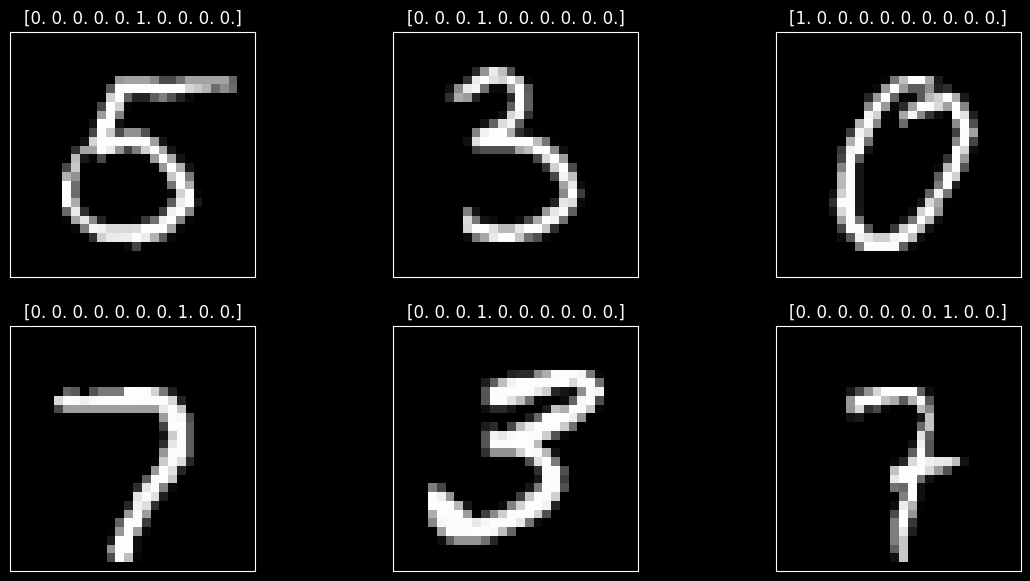

In [133]:
# Создаю набор данных.
imgs, targets = load_mnist_simple()

row = 2
col = 3
idxs = np.random.randint(0, 60000, row*col)
fig, ax = plt.subplots(row, col, figsize=(14, 7))
for i, idx in enumerate(idxs):
    img, one_hot = imgs[idx], targets[idx]
    ax[i//col, i%col].imshow(img, cmap='gray')
    ax[i//col, i%col].set_title(f"{one_hot}")
    ax[i//col, i%col].set_xticks([])
    ax[i//col, i%col].set_yticks([])

plt.show()

Epoch [1/50], train_loss = 0.3701, val_loss = 0.2081


Epoch [2/50], train_loss = 0.1909, val_loss = 0.1632


Epoch [3/50], train_loss = 0.1420, val_loss = 0.1338


Epoch [4/50], train_loss = 0.1142, val_loss = 0.1326


Epoch [5/50], train_loss = 0.0993, val_loss = 0.1171


...

Epoch [46/50], train_loss = 0.0015, val_loss = 0.0903


Epoch [47/50], train_loss = 0.0013, val_loss = 0.0913


Epoch [48/50], train_loss = 0.0013, val_loss = 0.0905


Epoch [49/50], train_loss = 0.0013, val_loss = 0.0920


Epoch [50/50], train_loss = 0.0012, val_loss = 0.0906

После 50 эпох обучения:
	train_loss = 0.0012, train_acc = 1.0000
	val_loss   = 0.0906, val_acc   = 0.9770


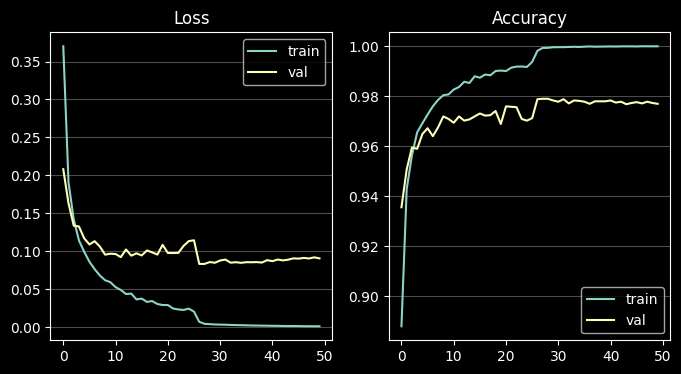

In [134]:
seed = 1961

# Сначала отделяем тест
t_img, test_img, t_target, test_target = train_test_split(
    imgs, targets, test_size=0.1, random_state=seed, stratify=np.argmax(targets, axis=1)
)
# Затем делим оставшееся на train/val
train_img, val_img, train_target, val_target = train_test_split(
    t_img, t_target, test_size=0.111, random_state=seed, stratify=np.argmax(t_target, axis=1)
)

# Данные для обучения
train_data = {
    'train': (train_img, train_target),
    'val': (val_img, val_target),
}

# Функция потерь
loss_model = CrossEntropyLoss()

# Оптимизатор
opt = AdamW()

W1, b1, W2, b2 = train(
    loss_model,
    opt,
    train_data,
    in_features = 28*28,
    hidden_size = 128,
    out_features = 10,
    init_mode = "uniform",
    batch_size = 64,
    epochs = 50,
    shuffle = True,
    norm = True,
    seed = seed
)

In [135]:
"""    Test start    """
imgs_batches, targets_batches = data_loader(
    (test_img, test_target),
    in_features = 28*28, 
    out_features = 10,
    batch_size = 64,
    epoch = 1,
    shuffle = False,
    seed = seed,
)

imgs_batches = normalize(imgs_batches)

correct = 0
total = 0
batch_losses = []
for batch_idx, (img_batch, target_batch) in enumerate(zip(imgs_batches, targets_batches)):
    # Прямой проход \ Forward
    out1 = img_batch @ W1 + b1
    act1 = relu(out1)
    pred = act1 @ W2 + b2
    # Функция потерь \ Loss
    loss = loss_model(pred, target_batch)
    batch_losses.append(loss)

    # Подсчёт метрики
    target_label = to_label(target_batch)
    pred_label = to_label(pred)
    correct += (pred_label == target_label).sum().item()
    total += target_label.size
    
test_acc = correct / total
test_loss = np.mean(batch_losses).item()

print(f"Качество сети на тестовой выборке:")
print(f"\ttest_loss = {test_loss:.4f}, test_acc = {test_acc:.4f}")

Качество сети на тестовой выборке:
	test_loss = 0.1288, test_acc = 0.9730
